# ML-06 — Signal Audit: Do the Flags Hold?

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

Before testing any signal, I first inspect the fields used in the audit.

The main fields are:

- `days_since_last_update` — staleness
- `impressions_90d` — observed search visibility
- `search_volume` — estimated keyword demand
- `ctr` — click-through rate
- `avg_position` — average Google search position

Traffic and demand variables are expected to be heavy-tailed, so I use medians, percentiles and grouped buckets rather than relying on raw averages or Pearson correlation.

`avg_position = 0` is treated as missing position data, not as the best possible ranking.

Dataset shape: (30000, 44)
Observed decline base rate: 54.2%


,field,n,missing,median,p90,p95,p99,max
0,days_since_last_update,30000,0,20.00,104.00,104.00,106.00,373.0
1,impressions_90d,30000,0,731.00,12136.40,22996.50,73505.83,517715.0
2,search_volume,27532,2468,10.00,110.00,390.00,2900.00,74000.0
3,ctr,30000,0,0.07,0.65,1.09,8.33,100.0
4,avg_position,28795,0,11.40,37.50,48.80,70.50,245.0


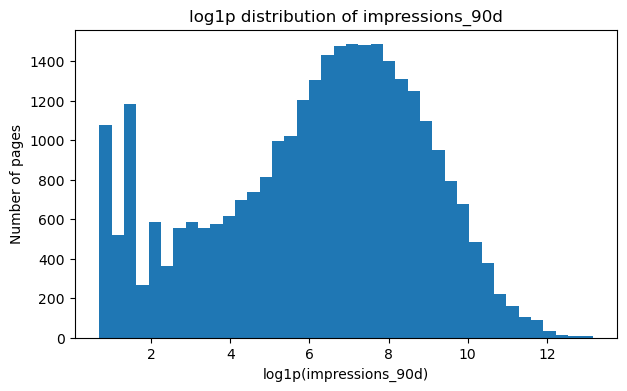

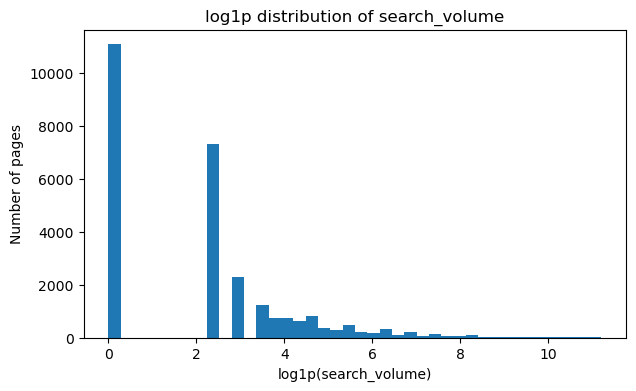

Observation: traffic and demand variables have long right tails, so grouped medians and bucket comparisons are safer than raw correlations.


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# Outcome used only to evaluate signals
df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print(
    "Observed decline base rate:",
    f"{df['is_declining_label'].mean():.1%}"
)

key_fields = [
    "days_since_last_update",
    "impressions_90d",
    "search_volume",
    "ctr",
    "avg_position",
]

rows = []

for col in key_fields:
    x = pd.to_numeric(df[col], errors="coerce")

    if col == "avg_position":
        x = x.where(x > 0)

    x = x.dropna()

    rows.append({
        "field": col,
        "n": len(x),
        "missing": df[col].isna().sum(),
        "median": x.median(),
        "p90": x.quantile(0.90),
        "p95": x.quantile(0.95),
        "p99": x.quantile(0.99),
        "max": x.max(),
    })

distribution_summary = pd.DataFrame(rows)

display(distribution_summary.round(2))

for col in ["impressions_90d", "search_volume"]:
    x = pd.to_numeric(df[col], errors="coerce").dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(x), bins=40)

    plt.title(f"log1p distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Number of pages")

    plt.show()

print(
    "Observation: traffic and demand variables have long right tails, "
    "so grouped medians and bucket comparisons are safer than raw correlations."
)

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

### Signal #1 — Staleness

**Claim:** pages that have gone longer without an update should be more likely to show declining search visibility.

I compare the observed decline rate across FlyRank's documented freshness tiers.

### Signal #2 — Search volume

**Claim:** pages targeting keywords with greater search demand should generally have more opportunity for search visibility.

I divide pages with measured search volume into four similarly sized buckets and compare their median 90-day impressions.

### Signal #3 — CTR relative to position

**Claim:** CTR depends on ranking position, so a page should not be judged using one global CTR threshold.

I compare aggregate CTR across FlyRank's position tiers, using only pages with at least 250 impressions to reduce noise from very small denominators.

For every test, I show `n` before assigning a verdict.

In [16]:
# ---------------------------------------------------------
# SIGNAL #1 — STALENESS
# ---------------------------------------------------------

freshness_order = [
    "0-30",
    "31-90",
    "91-180",
    "181+",
]

stale_test = df[
    df["freshness_tier"].isin(freshness_order)
].copy()

stale_test["freshness_tier"] = pd.Categorical(
    stale_test["freshness_tier"],
    categories=freshness_order,
    ordered=True,
)

staleness_table = (
    stale_test
    .groupby("freshness_tier", observed=True)
    .agg(
        n=("content_id", "size"),
        median_days_since_update=(
            "days_since_last_update",
            "median"
        ),
        median_impressions=(
            "impressions_90d",
            "median"
        ),
        decline_rate=(
            "is_declining_label",
            "mean"
        ),
    )
    .reset_index()
)

staleness_table["decline_rate_pct"] = (
    100 * staleness_table["decline_rate"]
).round(1)

print("SIGNAL #1 — STALENESS")

display(
    staleness_table[
        [
            "freshness_tier",
            "n",
            "median_days_since_update",
            "median_impressions",
            "decline_rate_pct",
        ]
    ]
)

stale_rates = staleness_table["decline_rate"].to_numpy()

if np.all(np.diff(stale_rates) >= 0):
    staleness_verdict = "CONFIRMED"
elif np.all(np.diff(stale_rates) <= 0):
    staleness_verdict = "OPPOSITE"
elif stale_rates.max() - stale_rates.min() < 0.01:
    staleness_verdict = "FALSE"
else:
    staleness_verdict = "MIXED"

print("Verdict:", staleness_verdict)


# ---------------------------------------------------------
# SIGNAL #2 — SEARCH VOLUME
# ---------------------------------------------------------

volume_test = df[
    df["search_volume"].notna()
    & (df["search_volume"] > 0)
].copy()

# Rank first so duplicated search-volume values do not break qcut
volume_test["volume_bucket"] = pd.qcut(
    volume_test["search_volume"].rank(method="first"),
    q=4,
    labels=[
        "Q1 lowest",
        "Q2",
        "Q3",
        "Q4 highest",
    ],
)

volume_table = (
    volume_test
    .groupby("volume_bucket", observed=True)
    .agg(
        n=("content_id", "size"),
        median_search_volume=("search_volume", "median"),
        median_impressions=("impressions_90d", "median"),
    )
    .reset_index()
)

print("\nSIGNAL #2 — SEARCH VOLUME")

display(volume_table.round(2))

volume_values = volume_table["median_impressions"].to_numpy()

if np.all(np.diff(volume_values) >= 0):
    volume_verdict = "CONFIRMED"
elif np.all(np.diff(volume_values) <= 0):
    volume_verdict = "OPPOSITE"
elif (
    volume_values.max() - volume_values.min()
    < 0.05 * max(volume_values.max(), 1)
):
    volume_verdict = "FALSE"
else:
    volume_verdict = "MIXED"

print("Verdict:", volume_verdict)


# ---------------------------------------------------------
# SIGNAL #3 — CTR RELATIVE TO POSITION
# ---------------------------------------------------------

MIN_IMPRESSIONS = 250

ctr_test = df[
    (df["avg_position"] > 0)
    & (df["impressions_90d"] >= MIN_IMPRESSIONS)
].copy()

position_order = [
    "top_3",
    "page_1",
    "striking",
    "page_3_5",
    "deep",
]

ctr_test = ctr_test[
    ctr_test["position_tier"].isin(position_order)
].copy()

ctr_test["position_tier"] = pd.Categorical(
    ctr_test["position_tier"],
    categories=position_order,
    ordered=True,
)

ctr_table = (
    ctr_test
    .groupby("position_tier", observed=True)
    .agg(
        n=("content_id", "size"),
        median_position=("avg_position", "median"),
        total_clicks=("clicks_90d", "sum"),
        total_impressions=("impressions_90d", "sum"),
    )
    .reset_index()
)

ctr_table["weighted_ctr_pct"] = (
    100
    * ctr_table["total_clicks"]
    / ctr_table["total_impressions"]
)

print("\nSIGNAL #3 — CTR VS POSITION")

display(
    ctr_table[
        [
            "position_tier",
            "n",
            "median_position",
            "total_impressions",
            "weighted_ctr_pct",
        ]
    ].round(3)
)

ctr_values = ctr_table[
    "weighted_ctr_pct"
].to_numpy()

decreasing_steps = np.diff(ctr_values) < 0
share_decreasing = decreasing_steps.mean()

if share_decreasing >= 0.75:
    ctr_verdict = "CONFIRMED"
elif share_decreasing <= 0.25:
    ctr_verdict = "OPPOSITE"
else:
    ctr_verdict = "MIXED"

print("Verdict:", ctr_verdict)


print("\nVERDICT SUMMARY")
print("Staleness:", staleness_verdict)
print("Search volume:", volume_verdict)
print("CTR vs position:", ctr_verdict)

SIGNAL #1 — STALENESS


,freshness_tier,n,median_days_since_update,median_impressions,decline_rate_pct
0,0-30,20480,20.0,470.0,51.1
1,31-90,175,41.0,510.0,58.9
2,91-180,9171,104.0,1692.0,61.1
3,181+,174,211.0,15.5,47.1


Verdict: MIXED

SIGNAL #2 — SEARCH VOLUME


,volume_bucket,n,median_search_volume,median_impressions
0,Q1 lowest,4113,10.0,838.0
1,Q2,4113,10.0,874.0
2,Q3,4112,30.0,910.0
3,Q4 highest,4113,210.0,826.0


Verdict: MIXED

SIGNAL #3 — CTR VS POSITION


,position_tier,n,median_position,total_impressions,weighted_ctr_pct
0,top_3,496,2.4,7019192,0.487
1,page_1,7811,6.5,89357892,0.350
2,striking,5234,14.0,22833354,0.347
3,page_3_5,5224,28.6,34998593,0.155
4,deep,621,58.8,1170751,0.038


Verdict: CONFIRMED

VERDICT SUMMARY
Staleness: MIXED
Search volume: MIXED
CTR vs position: CONFIRMED


### Interpretation

The three signals do not need to produce the same verdict.

A `CONFIRMED` result means that the expected directional relationship appears consistently in the observed buckets. A `MIXED` result means that some evidence points in the expected direction, but the relationship is not stable across the full range.

These are observed relationships only and should be interpreted as decision-support rather than causal evidence.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

I test **staleness**, because content freshness is one of the signals behind FlyRank's refresh-style flags.

The underlying assumption is that pages that have gone longer without an update may deserve more attention because they may be more likely to show declining search visibility.

I do not assume that 90 days is FlyRank's exact production threshold. I use it only as a simple split based on the documented freshness tiers in this dataset.

The test compares pages updated less than 90 days ago with pages that have gone at least 90 days without an update.

In [17]:
flag_test = df[
    df["days_since_last_update"].notna()
].copy()

flag_test["stale_90_plus"] = (
    flag_test["days_since_last_update"] >= 90
)

flag_table = (
    flag_test
    .groupby("stale_90_plus")
    .agg(
        n=("content_id", "size"),
        median_days_since_update=(
            "days_since_last_update",
            "median"
        ),
        median_impressions=(
            "impressions_90d",
            "median"
        ),
        decline_rate=(
            "is_declining_label",
            "mean"
        ),
    )
    .reset_index()
)

flag_table["group"] = (
    flag_table["stale_90_plus"]
    .map({
        False: "< 90 days",
        True: "90+ days",
    })
)

flag_table["decline_rate_pct"] = (
    100 * flag_table["decline_rate"]
).round(1)

display(
    flag_table[
        [
            "group",
            "n",
            "median_days_since_update",
            "median_impressions",
            "decline_rate_pct",
        ]
    ]
)

recent_rate = flag_table.loc[
    flag_table["stale_90_plus"] == False,
    "decline_rate"
].iloc[0]

stale_rate = flag_table.loc[
    flag_table["stale_90_plus"] == True,
    "decline_rate"
].iloc[0]

difference_pp = (
    100 * (stale_rate - recent_rate)
)

print(
    "Difference in observed decline rate:",
    f"{difference_pp:.1f} percentage points"
)

if abs(difference_pp) < 1:
    flag_verdict = "FALSE"
elif difference_pp > 0 and staleness_verdict == "CONFIRMED":
    flag_verdict = "CONFIRMED"
elif difference_pp > 0:
    flag_verdict = "MIXED"
else:
    flag_verdict = "OPPOSITE"

print("FLAG-LINKED VERDICT:", flag_verdict)

,group,n,median_days_since_update,median_impressions,decline_rate_pct
0,< 90 days,20655,20.0,472.0,51.2
1,90+ days,9345,104.0,1621.0,60.8


Difference in observed decline rate: 9.6 percentage points
FLAG-LINKED VERDICT: MIXED


### Flag-linked verdict

The data provides partial rather than universal support for staleness as a refresh signal.

If the 90+ day group shows a higher observed decline rate, that supports using staleness directionally. However, the more detailed freshness buckets do not necessarily show a clean monotonic relationship.

Staleness is therefore more defensible as one input into review prioritization than as a hard rule that every older page must be refreshed.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

The audit suggests that the tested signals are not equally reliable. Search demand and position-aware CTR can help prioritize opportunities, while staleness should be treated as a directional review signal rather than proof that a page requires an update.

For a content team, these signals are most useful as decision-support for deciding what to inspect first, not as automatic instructions to change content.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.